## Kunskapskontroll 1 - del 2

### Kapitel 4 - kodfråga 15

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from PIL import Image, ImageFilter

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.ensemble import VotingClassifier


In [2]:
# Load the MNIST dataset
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
# Prepare the data
X = mnist.data
y = mnist.target.astype(int) # make sure target is integer type for classification

/Users/opheliathomasson/Documents/TUC_datamanager/statistik_och_dataanlys/.venv/lib/python3.14/site-packages/sklearn/datasets/_arff_parser.py:446: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  frame[col] = frame[col].cat.rename_categories(st

In [3]:
print(y.shape) # show the shape of the target variable
print(X.shape) # show the shape of the feature data


(70000,)
(70000, 784)


In [4]:
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [5]:
model = RandomForestClassifier(random_state=42) # create a random forest classifier

In [6]:
model.fit(X_train, y_train) # fit the model to the training data

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [7]:
y_pred = model.predict(X_test) # make predictions on the test set

print(classification_report(y_test, y_pred)) # print the classification report for the test set

              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1343
           1       0.98      0.98      0.98      1600
           2       0.95      0.97      0.96      1380
           3       0.96      0.95      0.95      1433
           4       0.96      0.97      0.96      1295
           5       0.97      0.96      0.97      1273
           6       0.98      0.98      0.98      1396
           7       0.97      0.97      0.97      1503
           8       0.96      0.95      0.96      1357
           9       0.96      0.95      0.95      1420

    accuracy                           0.97     14000
   macro avg       0.97      0.97      0.97     14000
weighted avg       0.97      0.97      0.97     14000



In [8]:
# Load and preprocess the image in a format suitable for prediction
img = Image.open("my_number_4.png").convert("L")
img_array = np.array(img) 

In [9]:
# Find the light number in the image
coords = np.argwhere(img_array > 200)

y_min, x_min = coords.min(axis=0)
y_max, x_max = coords.max(axis=0)

In [10]:
# Crop the image to the bounding box of the light number
cropped = img_array[y_min:y_max+1, x_min:x_max+1]
cropped_img = Image.fromarray(cropped)

In [11]:
# Resize the cropped image to 20x20 pixels, so we can add a border to make it 28x28 pixels
cropped_img = cropped_img.resize((20, 20))

In [12]:
# Create a new 28x28 image and paste the resized cropped image in the center, 
# to match the input format of the MNIST dataset and have padding around the digit
final_img = Image.new("L", (28, 28), 0)
paste_x = (28 - cropped_img.width) // 2
paste_y = (28 - cropped_img.height) // 2
final_img.paste(cropped_img, (paste_x, paste_y))

In [13]:
# Apply a slight Gaussian blur to reduce noise and make the digit more similar to the MNIST style
final_img = final_img.filter(ImageFilter.GaussianBlur(radius=1))

In [14]:
# Convert the final image to a numpy array 
final_img_array = np.array(final_img)

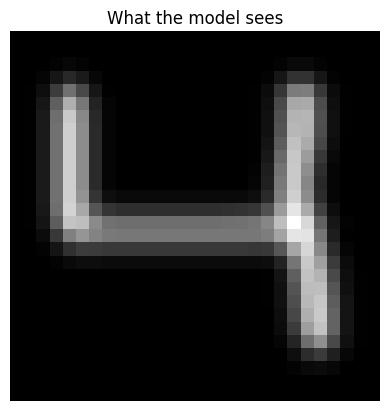

In [15]:
# Visualize the final preprocessed image to see what the model will see
plt.imshow(final_img_array, cmap="gray")
plt.title("What the model sees")
plt.axis("off")
plt.show()

In [16]:
# Reshape the image array to match the input shape expected by the model (1, 784)
final_img_array = final_img_array.reshape(1, 784)

In [17]:
# Make a prediction using the trained model
prediction = model.predict(final_img_array)
print(f"The model predicts the digit is: {prediction[0]}") 

The model predicts the digit is: 4
